# iSCORS deliverable — condensation axes (tidy, **memory-optimized version**: full-load + CACHE)

Loads the video **once** (streaming, RAM-capped) at the top, then three sections:
1. **Paper replication** — gamma, CV², slope-3 condensation, y-intercept (+ optional Pearson vs the .mat Cond_map).
2. **Single-cell most-reproducible axis** — reliability-max (cross-half GEVD) and the X⊥Y residual.
3. **Multi-axis decomposition** — G(τ) GEVD axis 1/2 and de-nuisanced ICA comp 1/2.

Conventions (so results are reproducible):
- **ICA order/sign are arbitrary in FastICA** → fixed: sparse (high |kurtosis|) = comp 1, heavy tail positive.
- **De-nuisance basis = poly3 + radial vignetting**, identical wherever ICA is used.
- The temporal flat-field cancels in C(τ)/C(0), so g_norm is insensitive to it.


In [1]:
# ── setup: clone/update repo from GitHub, mount Drive, install deps ──
import os, sys, subprocess
REPO = 'https://github.com/breezy90126/iscors-net.git'; BRANCH = 'claude/dazzling-newton-qz0ffj'
REPO_DIR = '/content/iscors-net'
try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except Exception: pass
if os.path.isdir(REPO_DIR):
    for c in (['git', '-C', REPO_DIR, 'fetch', 'origin'], ['git', '-C', REPO_DIR, 'checkout', BRANCH],
              ['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH]): subprocess.run(c, check=False)
else:
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO, REPO_DIR], check=False)
os.chdir(REPO_DIR); sys.path.insert(0, REPO_DIR)
subprocess.run(['pip', 'install', '-q', 'tifffile', 'scipy', 'gradio', 'scikit-learn', 'scikit-image'], check=False)
print('setup done:', os.getcwd())

# ── imports used throughout ──
import gc, zipfile, numpy as np, matplotlib.pyplot as plt, tifffile
from scipy.ndimage import zoom
from scipy.linalg import eigh as geigh
from scipy.stats import pearsonr, kurtosis
from sklearn.decomposition import FastICA
from utils.gpu_iscors_fit import streaming_acf, fit_gamma_alpha_batched


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
setup done: /content/iscors-net


In [2]:
# ── config (EDIT paths; same as the runner notebooks) ──
ZIP_PATH    = '/content/drive/MyDrive/iscors_test/large_file.zip'   # .zip or a .tif
VIDEO_FNAME = 'COBRI_rarw_video.tif'
EXTRACT_DIR = '/content/real_data'
MASK_PATH   = 'data/condensation_mask.tif'
MAT_FNAME   = 'Output_iSCORS_map.mat'        # optional, for the Cond_map validation
N_FRAMES = 5000; BIN_FACTOR = 2; RECON_TAUS = (1, 2, 4, 8, 16, 32, 48, 64, 96, 128)
GAMMA_SCALE = 2.0; CONDENSATION_SLOPE = 3.0; DSTAR_FROM = 'gamma'
BIN = BIN_FACTOR; SLOPE = CONDENSATION_SLOPE                 # aliases used by the sections
print('config ready')


config ready


In [3]:
# ── loaders (full-load: chunk-read + bin → ~2GB binned array) ──
import os, sys, gc, zipfile, numpy as np, tifffile
from scipy.ndimage import gaussian_filter, zoom
REPO_DIR = '/content/iscors-net'
if os.path.isdir(REPO_DIR):
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path: sys.path.insert(0, REPO_DIR)
import importlib, utils.gpu_iscors_fit as _gf; importlib.reload(_gf)
from utils.gpu_iscors_fit import gpu_fit_maps, compute_density, compute_g_norm_torch, condensation_projection

def load_video(path, fname=None, n_frames=2000, bin_factor=2):
    if str(path).lower().endswith('.zip'):
        ed = globals().get('EXTRACT_DIR', '/content/real_data'); os.makedirs(ed, exist_ok=True)
        def _find(root, name):
            for dp, _, fs in os.walk(root):
                if name in fs: return os.path.join(dp, name)
            return None
        vp = _find(ed, fname)
        if not vp:
            with zipfile.ZipFile(path) as z: z.extractall(ed)
            vp = _find(ed, fname)
        assert vp, f'{fname} not found in zip'
    else:
        vp = path
    H0, W0 = tifffile.imread(vp, key=0).shape
    Hb, Wb = H0 // bin_factor, W0 // bin_factor
    with tifffile.TiffFile(vp) as tf:
        try:    total = int(tf.series[0].shape[0])
        except Exception: total = len(tf.pages)
    n = min(n_frames, total); Hc, Wc = Hb * bin_factor, Wb * bin_factor
    raw = np.empty((n, Hb, Wb), np.float32)
    for s in range(0, n, 100):
        e = min(s + 100, n); ch = tifffile.imread(vp, key=range(s, e)).astype(np.float32)
        raw[s:e] = ch[:, :Hc, :Wc].reshape(e - s, Hb, bin_factor, Wb, bin_factor).mean((2, 4))
    print(f'[load] {os.path.basename(vp)}: {n}/{total} frames  binned {raw.shape}')
    return raw

def preprocess(raw):
    ff = raw / (np.median(raw, axis=0)[None] + 1e-10)
    for t in range(len(ff)): ff[t] /= (gaussian_filter(ff[t], 4) + 1e-10)
    return ff

def load_mask(shape):
    mk = np.asarray(tifffile.imread(MASK_PATH)).squeeze()
    if mk.ndim == 3: mk = mk[..., 0]
    if mk.shape != shape: mk = zoom(mk, (shape[0] / mk.shape[0], shape[1] / mk.shape[1]), order=0)
    bd = np.zeros(shape, bool); bd[0, :] = bd[-1, :] = bd[:, 0] = bd[:, -1] = True
    return mk == min(np.unique(mk), key=lambda z: (mk[bd] == z).mean())   # interior = nucleus
print('loaders defined')


loaders defined


In [4]:
# ── load ONCE (full) → all per-pixel maps for full + halves, then free the video ──
raw = load_video(ZIP_PATH, VIDEO_FNAME, N_FRAMES, BIN_FACTOR); vp = preprocess(raw); del raw; gc.collect()
h = vp.shape[0] // 2
def _maps(seg):
    d, _ = compute_density(seg, min_cv=0.005)
    g, _c, _z = compute_g_norm_torch(seg, RECON_TAUS, norm='nor1', min_cv=0.005)
    f = gpu_fit_maps(seg, recon_taus=RECON_TAUS, n_components=1, global_alpha=True,
                     gamma_scale=GAMMA_SCALE, min_cv=0.005, n_steps=400, verbose=False)
    return f['gamma'].astype(np.float32), d.astype(np.float32), g.cpu().numpy().astype(np.float32)
gamma, dens, G = _maps(vp)                 # full
g1g, g1d, G1   = _maps(vp[:h])             # first half
g2g, g2d, G2   = _maps(vp[h:])             # second half
del vp; gc.collect()
try:
    import torch; torch.cuda.empty_cache()
except Exception: pass
nuc = load_mask(dens.shape) & np.isfinite(gamma)
_lg = lambda a: np.log10(np.clip(a, 1e-12, None))
X,  Y  = _lg(1 / np.clip(gamma, 1e-6, None)), _lg(dens)
X1, Y1 = _lg(1 / np.clip(g1g, 1e-6, None)), _lg(g1d)
X2, Y2 = _lg(1 / np.clip(g2g, 1e-6, None)), _lg(g2d)
print('loaded once (video freed). nucleus px:', int(nuc.sum()))


# ===== CACHE architecture =====
CACHE = {
    "X": X, "Y": Y, "G": G,
    "X1": X1, "Y1": Y1, "G1": G1,
    "X2": X2, "Y2": Y2, "G2": G2,
    "nuc": nuc,
}

# Drop large movie arrays immediately
try:
    del vp
except:
    pass
gc.collect()


[load] COBRI_rarw_video.tif: 5000/5001 frames  binned (5000, 320, 320)
loaded once (video freed). nucleus px: 38643


45

In [5]:
# ===== Read from CACHE only =====
X=CACHE['X']; Y=CACHE['Y']; G=CACHE['G']
X1=CACHE['X1']; Y1=CACHE['Y1']; G1=CACHE['G1']
X2=CACHE['X2']; Y2=CACHE['Y2']; G2=CACHE['G2']
nuc=CACHE['nuc']

# ── helpers (also register maps for the viewer) ──
m = nuc & np.isfinite(X) & np.isfinite(Y)
ALL_MAPS = {}
def _full(vec_on_m):
    z = np.full(nuc.shape, np.nan); z[m] = vec_on_m; return z
def _gevd(a1, a2):
    Cg = (a1.T @ a2) / a1.shape[0]; Cg = (Cg + Cg.T) / 2
    v, w = geigh(Cg, np.cov(np.vstack([a1, a2]).T)); o = np.argsort(v)[::-1]
    return v[o], w[:, o]
def show(items, title):
    n = len(items); fig, ax = plt.subplots(1, n, figsize=(4.2*n, 4.2)); ax = np.atleast_1d(ax)
    for a, (t, d, cm) in zip(ax, items):
        ALL_MAPS[t] = (d, cm)
        im = a.imshow(d, cmap=cm, vmin=np.nanpercentile(d, 2), vmax=np.nanpercentile(d, 98))
        a.set_title(t, fontsize=10); a.axis('off'); plt.colorbar(im, ax=a, fraction=0.046)
    fig.suptitle(title); plt.tight_layout(); plt.show()


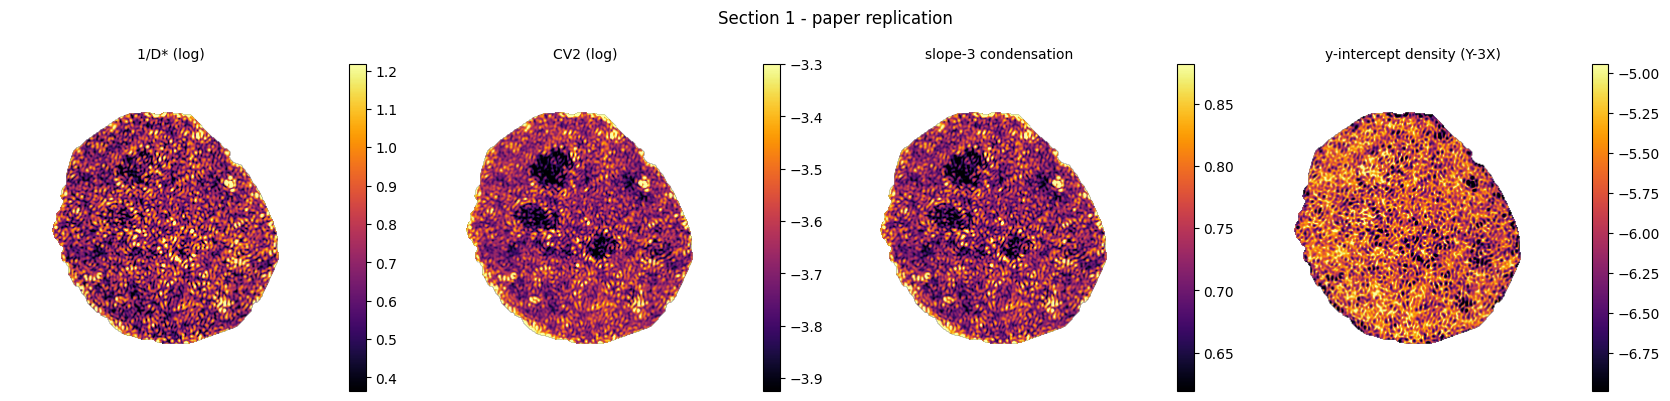

Pearson(our slope-3 condensation, .mat Cond_map) = 0.89


In [6]:
# ===== Read from CACHE only =====
X=CACHE['X']; Y=CACHE['Y']; G=CACHE['G']
X1=CACHE['X1']; Y1=CACHE['Y1']; G1=CACHE['G1']
X2=CACHE['X2']; Y2=CACHE['Y2']; G2=CACHE['G2']
nuc=CACHE['nuc']

# ── Section 1 — paper replication ──
b3 = float((Y[m] - SLOPE * X[m]).mean())
cond = _full(((X + SLOPE * Y - SLOPE * b3) / (1 + SLOPE ** 2))[m])
show([('1/D* (log)',                 _full(X[m]),               'inferno'),
      ('CV2 (log)',                  _full(Y[m]),               'inferno'),
      ('slope-3 condensation',       cond,                      'inferno'),
      ('y-intercept density (Y-3X)', _full((Y - SLOPE * X)[m]), 'inferno')],
     'Section 1 - paper replication')

def _find(name):
    for dp, _, fs in os.walk(EXTRACT_DIR):
        if name in fs: return os.path.join(dp, name)
mp = _find(MAT_FNAME)
if mp:
    try:
        import scipy.io; mat = scipy.io.loadmat(mp)
    except NotImplementedError:
        import h5py; mat = {k: np.array(v) for k, v in h5py.File(mp, 'r').items()}
    if 'Cond_map' in mat:
        cg = np.asarray(mat['Cond_map']).astype(float).squeeze()
        o = np.rot90(np.flipud(cg), -1)
        if o.shape != nuc.shape: o = zoom(o, (nuc.shape[0]/o.shape[0], nuc.shape[1]/o.shape[1]), order=1)
        ok = nuc & np.isfinite(o) & np.isfinite(cond)
        print('Pearson(our slope-3 condensation, .mat Cond_map) =', round(pearsonr(o[ok], cond[ok])[0], 3))
else:
    print('(.mat Cond_map not found under EXTRACT_DIR - skipping validation)')


In [ ]:
# ===== Read from CACHE only =====
X=CACHE['X']; Y=CACHE['Y']; G=CACHE['G']
X1=CACHE['X1']; Y1=CACHE['Y1']; G1=CACHE['G1']
X2=CACHE['X2']; Y2=CACHE['Y2']; G2=CACHE['G2']
nuc=CACHE['nuc']

import gc
from scipy.linalg import eigh as geigh
from scipy.stats import pearsonr

# ── Section 2 — reliability-max axis + its ORTHOGONAL axis (replaces X⊥Y) ──
m  = nuc & np.isfinite(X)  & np.isfinite(Y)
mm = nuc & np.isfinite(X1) & np.isfinite(Y1) & np.isfinite(X2) & np.isfinite(Y2)
mX, mY = float(X[mm].mean()), float(Y[mm].mean())
sX, sY = float(X[mm].std()), float(Y[mm].std())
f1 = np.vstack([(X1[mm]-mX)/sX, (Y1[mm]-mY)/sY]).astype(np.float32)
f2 = np.vstack([(X2[mm]-mX)/sX, (Y2[mm]-mY)/sY]).astype(np.float32)
Csig = (f1 @ f2.T) / f1.shape[1]; Csig = (Csig + Csig.T) / 2
Ctot = np.cov(np.hstack([f1, f2]))
gval, Gv = geigh(Csig, Ctot)
v_rel  = Gv[:, -1]                                   # most-reproducible axis
v_perp = np.array([-v_rel[1], v_rel[0]])            # Euclidean-orthogonal to reliability-max

def _proj(vec, Xs, Ys): return vec[0]*(Xs-mX)/sX + vec[1]*(Ys-mY)/sY
def _rel(vec): return pearsonr(_proj(vec, X1, Y1)[mm], _proj(vec, X2, Y2)[mm])[0]

cond  = _full(_proj(v_rel,  X, Y)[m])
ortho = _full(_proj(v_perp, X, Y)[m])
print(f'reliability-max  r(halves) = {_rel(v_rel):.3f}   (theoretical λ={gval[-1]:.3f})')
print(f'relmax-orthogonal r(halves) = {_rel(v_perp):.3f}')

ALL_MAPS['reliability-max axis']    = (cond,  'inferno')
ALL_MAPS['relmax-orthogonal axis']  = (ortho, 'coolwarm')
show([('reliability-max axis', cond, 'inferno'),
      ('relmax-orthogonal axis', ortho, 'coolwarm')],
     'Section 2 - reproducible axis + its orthogonal')
del f1, f2, Csig, Ctot, Gv; gc.collect()


In [ ]:
# ===== Read from CACHE only =====
X=CACHE['X']; Y=CACHE['Y']; G=CACHE['G']
X1=CACHE['X1']; Y1=CACHE['Y1']; G1=CACHE['G1']
X2=CACHE['X2']; Y2=CACHE['Y2']; G2=CACHE['G2']
nuc=CACHE['nuc']

import gc
from scipy.linalg import eigh as geigh
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis

# ── Section 3 — generalized GEVD; de-ramp axis 2; FastICA re-run on the de-ramped pair; nucleoli-blue sign ──
m = nuc & np.isfinite(X) & np.isfinite(Y)
feat = lambda g, yl: np.concatenate([g.astype(np.float32), yl[..., None].astype(np.float32)], -1)
F1, F2, Ff = feat(G1, Y1)[m], feat(G2, Y2)[m], feat(G, Y)[m]
mu = (F1.mean(0) + F2.mean(0)) / 2; sd = (F1.std(0) + F2.std(0)) / 2 + 1e-9
_, W = _gevd((F1 - mu) / sd, (F2 - mu) / sd)
pj = ((Ff - mu) / sd) @ W

# sign: force NUCLEOLI to be BLUE (negative) on BOTH GEVD axes — nucleoli = lowest-density pixels
Ym = Y[m]; nucleoli = Ym < np.percentile(Ym, 12)
if pj[nucleoli, 0].mean() > pj[~nucleoli, 0].mean(): pj[:, 0] = -pj[:, 0]
if pj[nucleoli, 1].mean() > pj[~nucleoli, 1].mean(): pj[:, 1] = -pj[:, 1]

# de-ramp GEVD axis 2 with a LINEAR plane [xa, ya, 1] — BEFORE ICA, not after
yy, xx = np.mgrid[0:nuc.shape[0], 0:nuc.shape[1]]
xa = ((xx[m]-xx[m].mean())/xx[m].std()).astype(np.float32); ya = ((yy[m]-yy[m].mean())/yy[m].std()).astype(np.float32)
Dr = np.vstack([xa, ya, np.ones_like(xa)]).T                              # LINEAR ramp basis
ramp = Dr @ np.linalg.lstsq(Dr, pj[:, 1], rcond=None)[0]
axis2_clean = pj[:, 1] - ramp

# re-run FastICA on GEVD axis 1 + de-ramped axis 2 (not the raw pair)
pj_clean = np.stack([pj[:, 0], axis2_clean], axis=1)
S = FastICA(2, random_state=0, whiten='unit-variance', max_iter=1000).fit_transform(pj_clean)
S = S[:, np.argsort([-abs(kurtosis(S[:, 0])), -abs(kurtosis(S[:, 1]))])]   # sort: sparse condensate axis first
condensate, other = S[:, 0].copy(), S[:, 1].copy()

# sign: force NUCLEOLI to be BLUE (negative) on BOTH final ICA axes — nucleoli = lowest-density pixels
if condensate[nucleoli].mean() > condensate[~nucleoli].mean(): condensate = -condensate
if other[nucleoli].mean()      > other[~nucleoli].mean():      other      = -other

# comp 1 / comp 2: comp 1 = the axis re-built from the de-ramped GEVD axis 2, comp 2 = sparse condensate
ALL_MAPS['G(tau) GEVD axis 1']      = (_full(pj[:, 0]),      'inferno')
ALL_MAPS['G(tau) GEVD axis 2']      = (_full(pj[:, 1]),      'inferno')
ALL_MAPS['G(tau) GEVD axis 2 (de-ramped)'] = (_full(axis2_clean), 'inferno')
ALL_MAPS['ICA comp 1']              = (_full(other),         'inferno')
ALL_MAPS['ICA comp 2 (condensate)'] = (_full(condensate),     'inferno')
show([('G(tau) GEVD axis 2', _full(pj[:, 1]), 'inferno'),
      ('fitted LINEAR ramp', _full(ramp),  'coolwarm'),
      ('G(tau) GEVD axis 2 (de-ramped)', _full(axis2_clean), 'inferno'),
      ('ICA comp 1 (re-run on de-ramped pair)',  _full(other), 'inferno'),
      ('ICA comp 2 (condensate)', _full(condensate), 'inferno')],
     'Section 3 - GEVD axis 2 de-ramped BEFORE ICA re-run; nucleoli blue on every axis')
del F1, F2, Ff, W, S, Dr; gc.collect()


In [ ]:
# ===== Read from CACHE only =====
X=CACHE['X']; Y=CACHE['Y']; G=CACHE['G']
X1=CACHE['X1']; Y1=CACHE['Y1']; G1=CACHE['G1']
X2=CACHE['X2']; Y2=CACHE['Y2']; G2=CACHE['G2']
nuc=CACHE['nuc']

# ── comparison grid: 5 rows × 2 cols (same method per row); left coolwarm / right viridis ──
def _z(d):
    s = d[nuc]; return (d - np.nanmean(s)) / (np.nanstd(s) + 1e-9)
# per-panel vmin/vmax override (default shared -2..3 scale); 'ICA comp 1' gets tighter,
# percentile-based limits because its z-scored range is dominated by a few outliers
_RANGE_OVERRIDE = {'ICA comp 1': (2, 98)}
def _vlims(name, zdata):
    pct = _RANGE_OVERRIDE.get(name)
    if pct is None:
        return -2, 3
    return np.nanpercentile(zdata[nuc], pct[0]), np.nanpercentile(zdata[nuc], pct[1])
rows = [('1/D* (log)',               'CV2 (log)'),
        ('slope-3 condensation',     'y-intercept density (Y-3X)'),
        ('reliability-max axis',     'relmax-orthogonal axis'),
        ('G(tau) GEVD axis 1',       'G(tau) GEVD axis 2'),
        ('ICA comp 1',               'ICA comp 2 (condensate)')]
row_note = ['', '', '', '  [full-ACF plane, not pure CV2/1/D*]', '  [de-nuisanced / ramp-removed]']
fig, ax = plt.subplots(5, 2, figsize=(9, 20))
for i, (left, right) in enumerate(rows):
    for j, (name, cmap) in enumerate([(left, 'coolwarm'), (right, 'viridis')]):
        a = ax[i, j]
        if name in ALL_MAPS:
            zdata = _z(ALL_MAPS[name][0])
            vmin, vmax = _vlims(name, zdata)
            im = a.imshow(zdata, cmap=cmap, vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=a, fraction=0.046)
            a.set_title(name + (row_note[i] if j == 0 else ''), fontsize=9)
        else:
            a.text(0.5, 0.5, f'{name}\n(run its section first)', ha='center', va='center', fontsize=8)
        a.axis('off')
fig.suptitle('iSCORS candidate axes - z-scored (left coolwarm / right viridis)', fontsize=14)
plt.tight_layout(); plt.show()


In [ ]:
# ── viewer: one plot whose selector (title) is a dropdown over the computed dimensions ──
import gradio as gr
def _render(name):
    d, cm = ALL_MAPS[name]
    fig, a = plt.subplots(figsize=(6, 6))
    im = a.imshow(d, cmap=cm, vmin=np.nanpercentile(d[nuc], 2), vmax=np.nanpercentile(d[nuc], 98))
    a.set_title(name, fontsize=11); a.axis('off'); plt.colorbar(im, ax=a, fraction=0.046)
    return fig
names = list(ALL_MAPS)
with gr.Blocks(title='iSCORS axes viewer') as demo:
    dd  = gr.Dropdown(names, value=names[0], label='維度')
    out = gr.Plot()
    dd.change(_render, dd, out)
    demo.load(lambda: _render(names[0]), None, out)
demo.launch(share=True)
